In [4]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Imports
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt

In [5]:
# Load data
# NOTE: Replace 'sample1.csv' with your actual dataset file path
data = pd.read_csv('P1G1.csv') 

# Scale the data
scaler = RobustScaler()
X_scaled = scaler.fit_transform(data)

In [6]:
# --- Model 1: Isolation Forest ---
iso_forest = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
iso_forest.fit(X_scaled)
iso_preds = iso_forest.predict(X_scaled)
data['Iso_Anomaly'] = np.where(iso_preds == 1, 0, 1)  # 1 = anomaly, 0 = normal

# --- Model 2: Local Outlier Factor (LOF) ---
# novelty=True is used here for consistency in prediction logic
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1, novelty=True)
lof.fit(X_scaled)
lof_preds = lof.predict(X_scaled)
data['LOF_Anomaly'] = np.where(lof_preds == 1, 0, 1)  # 1 = anomaly, 0 = normal

# --- Combined Model ---
# Logic: If either model flags it as an anomaly, it is flagged as an anomaly
data['Combined_Anomaly'] = (data['Iso_Anomaly'] + data['LOF_Anomaly']) / 2
data['Combined_Anomaly'] = np.where(data['Combined_Anomaly'] >= 0.5, 1, 0)

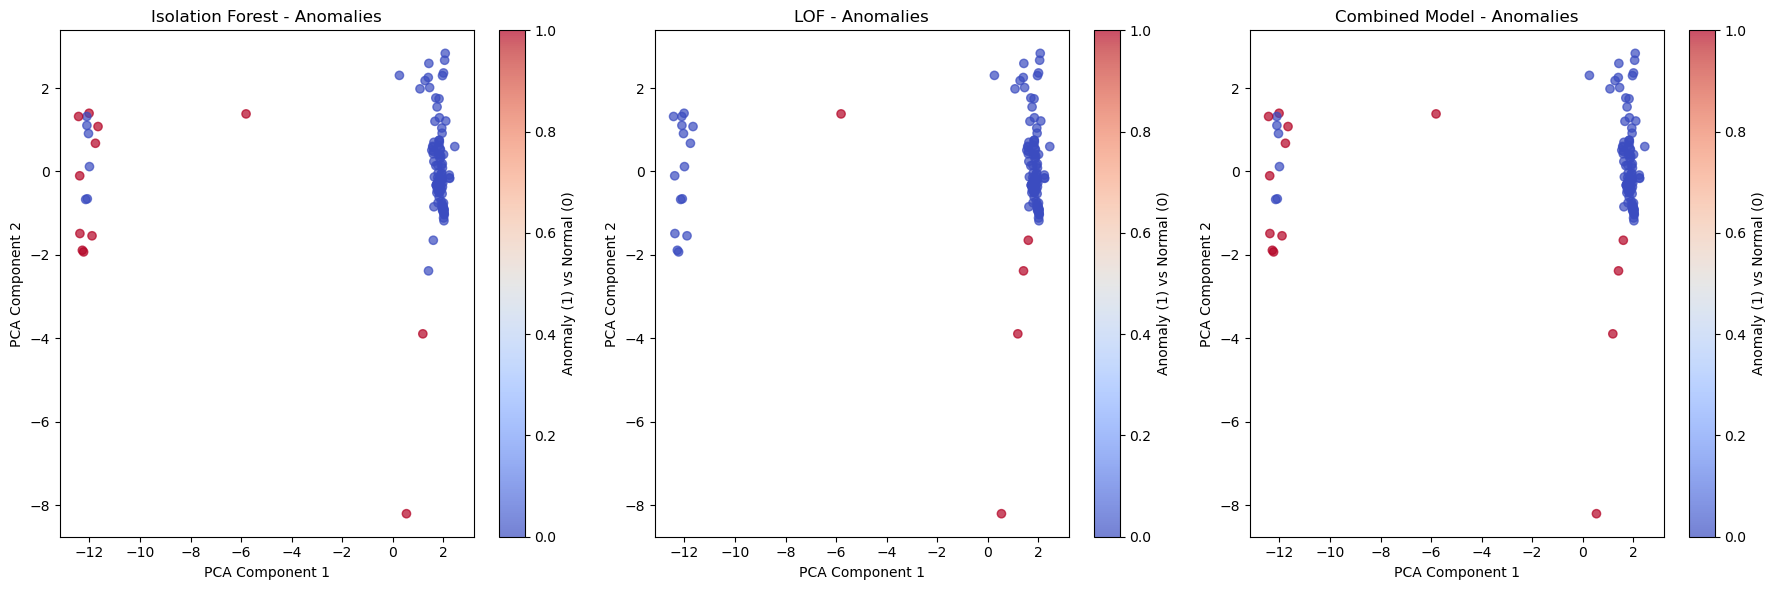

In [7]:
# --- Visualization (PCA) ---
pca = PCA(n_components=2)
data_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(18, 6))

# Plot 1: Isolation Forest
plt.subplot(1, 3, 1)
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=data['Iso_Anomaly'], cmap='coolwarm', alpha=0.7)
plt.title("Isolation Forest - Anomalies")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Anomaly (1) vs Normal (0)")

# Plot 2: LOF
plt.subplot(1, 3, 2)
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=data['LOF_Anomaly'], cmap='coolwarm', alpha=0.7)
plt.title("LOF - Anomalies")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Anomaly (1) vs Normal (0)")

# Plot 3: Combined
plt.subplot(1, 3, 3)
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=data['Combined_Anomaly'], cmap='coolwarm', alpha=0.7)
plt.title("Combined Model - Anomalies")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Anomaly (1) vs Normal (0)")

plt.tight_layout()
plt.show()

In [8]:
# --- Statistical Analysis ---
iso_anomalies = data[data['Iso_Anomaly'] == 1]
lof_anomalies = data[data['LOF_Anomaly'] == 1]
combined_anomalies = data[data['Combined_Anomaly'] == 1]

print("--- Isolation Forest Statistics ---")
print(iso_anomalies.describe())

print("\n--- LOF Statistics ---")
print(lof_anomalies.describe())

print("\n--- Combined Model Statistics ---")
print(combined_anomalies.describe())

--- Isolation Forest Statistics ---
              FSR1         FSR2         FSR3         FSR4  Iso_Anomaly  \
count    12.000000    12.000000    12.000000    12.000000         12.0   
mean   1668.083333   587.000000  3791.750000  3811.916667          1.0   
std    1467.293517  1166.618034   231.464164   192.464617          0.0   
min     730.000000     0.000000  3186.000000  3363.000000          1.0   
25%     769.500000     0.000000  3759.750000  3735.500000          1.0   
50%     955.000000    46.000000  3841.500000  3828.500000          1.0   
75%    1800.750000   253.000000  3944.750000  3967.000000          1.0   
max    4095.000000  3222.000000  3986.000000  4003.000000          1.0   

       LOF_Anomaly  Combined_Anomaly  
count    12.000000              12.0  
mean      0.250000               1.0  
std       0.452267               0.0  
min       0.000000               1.0  
25%       0.000000               1.0  
50%       0.000000               1.0  
75%       0.250000      

In [9]:
# --- Sensitivity Analysis ---
print("\n--- Sensitivity Analysis (Contamination Levels) ---")
for contamination in [0.05, 0.1, 0.15]:
    # Isolation Forest
    iso_temp = IsolationForest(n_estimators=100, contamination=contamination, random_state=42)
    iso_temp.fit(X_scaled)
    iso_count = np.sum(iso_temp.predict(X_scaled) == -1)
    
    # LOF
    lof_temp = LocalOutlierFactor(n_neighbors=20, contamination=contamination, novelty=True)
    lof_temp.fit(X_scaled)
    lof_count = np.sum(lof_temp.predict(X_scaled) == -1)
    
    print(f"Contamination {contamination}: IsoForest={iso_count} | LOF={lof_count}")


--- Sensitivity Analysis (Contamination Levels) ---
Contamination 0.05: IsoForest=6 | LOF=4
Contamination 0.1: IsoForest=12 | LOF=5
Contamination 0.15: IsoForest=18 | LOF=5


In [10]:
# --- Synthetic Anomaly Injection Test ---
print("\n--- Synthetic Anomaly Injection Test ---")
# Create synthetic outliers
synthetic_anomalies = data.sample(5, random_state=42).copy()
synthetic_anomalies += np.random.normal(50, 20, synthetic_anomalies.shape)

# Append to data
data_with_synthetic = pd.concat([data, synthetic_anomalies], ignore_index=True)

# Re-scale only the new synthetic data part (simplified for demo)
X_synthetic_scaled = scaler.transform(data_with_synthetic.drop(columns=['Iso_Anomaly', 'LOF_Anomaly', 'Combined_Anomaly']))

# Predict
iso_synthetic = iso_forest.predict(X_synthetic_scaled)
lof_synthetic = lof.predict(X_synthetic_scaled)

# Check last 5 rows (synthetic)
print(f"Isolation Forest detected synthetic anomalies: {np.sum(iso_synthetic[-5:] == -1)}")
print(f"LOF detected synthetic anomalies: {np.sum(lof_synthetic[-5:] == -1)}")



--- Synthetic Anomaly Injection Test ---
Isolation Forest detected synthetic anomalies: 1
LOF detected synthetic anomalies: 0
